# 👥 Predicción de Rotación de Empleados - Human Resources Analytics

## 🎯 Objetivo del Proyecto

Este proyecto tiene como objetivo desarrollar un modelo predictivo que identifique empleados con alta probabilidad de abandonar la empresa, permitiendo al departamento de Recursos Humanos implementar estrategias proactivas de retención de talento.

### 📊 Contexto de Negocio

La rotación de empleados representa uno de los mayores costos ocultos para las organizaciones:
- **Costo promedio por empleado que se va**: $15,000 - $25,000 (reclutamiento + entrenamiento)
- **Tiempo promedio de reemplazo**: 3-6 meses
- **Pérdida de conocimiento institucional**: Impacto inmensurable en productividad

### 🎯 Objetivos Específicos

1. **Predecir** qué empleados tienen mayor riesgo de abandonar la empresa
2. **Identificar** los factores clave que influyen en la decisión de abandono
3. **Optimizar** las estrategias de retención de talento
4. **Reducir** los costos asociados a la rotación de personal

### 📈 Métricas de Éxito

- **Precisión del modelo**: >85%
- **Recall para empleados que dejan**: >80%
- **Reducción de rotación esperada**: 15-20%
- **ROI estimado**: $500K - $1M anuales

---

## 📚 Importación de Librerías

Comenzamos importando las librerías necesarias para el análisis de datos, visualización y modelado de machine learning.

In [2]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline

In [ ]:
# Carga de datos usando rutas relativas para mayor portabilidad
import os
from pathlib import Path

# Obtener directorio actual del notebook
current_dir = Path.cwd()
data_path = current_dir / 'Human_Resources.csv'

# Verificar que el archivo existe
if data_path.exists():
    employee_df = pd.read_csv(data_path)
    print(f"✅ Dataset cargado exitosamente desde: {data_path}")
    print(f"📊 Dimensiones del dataset: {employee_df.shape[0]} filas x {employee_df.shape[1]} columnas")
else:
    print(f"❌ Error: No se encontró el archivo en {data_path}")
    
# Mostrar primeras filas del dataset
employee_df.head()

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,...,1,80,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,...,4,80,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,...,2,80,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,...,3,80,0,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,...,4,80,1,6,3,3,2,2,2,2


## 📂 Carga y Exploración Inicial de Datos

### 📋 Descripción del Dataset

Utilizamos el **IBM HR Analytics Employee Attrition Dataset**, que contiene información de 1,470 empleados con 35 características diferentes. 

**Variables principales incluidas:**
- **Demográficas**: Edad, género, estado civil, distancia al trabajo
- **Laborales**: Departamento, rol, nivel de trabajo, años en la empresa  
- **Compensación**: Salario mensual, incrementos salariales, opciones de acciones
- **Satisfacción**: Ratings de ambiente laboral, balance vida-trabajo, satisfacción laboral
- **Desarrollo**: Entrenamiento recibido, promociones, años con manager actual

### 🎯 Variable Objetivo
- **Attrition**: Indica si el empleado abandonó la empresa (Yes) o se quedó (No)

In [4]:
employee_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 35 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   Age                       1470 non-null   int64 
 1   Attrition                 1470 non-null   object
 2   BusinessTravel            1470 non-null   object
 3   DailyRate                 1470 non-null   int64 
 4   Department                1470 non-null   object
 5   DistanceFromHome          1470 non-null   int64 
 6   Education                 1470 non-null   int64 
 7   EducationField            1470 non-null   object
 8   EmployeeCount             1470 non-null   int64 
 9   EmployeeNumber            1470 non-null   int64 
 10  EnvironmentSatisfaction   1470 non-null   int64 
 11  Gender                    1470 non-null   object
 12  HourlyRate                1470 non-null   int64 
 13  JobInvolvement            1470 non-null   int64 
 14  JobLevel                

### 🔍 Análisis de Estructura y Tipos de Datos

Examinamos la estructura del dataset para entender los tipos de datos y identificar posibles valores faltantes.

In [5]:
employee_df.describe()

,Age,DailyRate,DistanceFromHome,Education,EmployeeCount,EmployeeNumber,EnvironmentSatisfaction,HourlyRate,JobInvolvement,JobLevel,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
count,1470.000000,1470.000000,1470.000000,1470.000000,1470.0,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,...,1470.000000,1470.0,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000
mean,36.923810,802.485714,9.192517,2.912925,1.0,1024.865306,2.721769,65.891156,2.729932,2.063946,...,2.712245,80.0,0.793878,11.279592,2.799320,2.761224,7.008163,4.229252,2.187755,4.123129
std,9.135373,403.509100,8.106864,1.024165,0.0,602.024335,1.093082,20.329428,0.711561,1.106940,...,1.081209,0.0,0.852077,7.780782,1.289271,0.706476,6.126525,3.623137,3.222430,3.568136
min,18.000000,102.000000,1.000000,1.000000,1.0,1.000000,1.000000,30.000000,1.000000,1.000000,...,1.000000,80.0,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000
25%,30.000000,465.000000,2.000000,2.000000,1.0,491.250000,2.000000,48.000000,2.000000,1.000000,...,2.000000,80.0,0.000000,6.000000,2.000000,2.000000,3.000000,2.000000,0.000000,2.000000
50%,36.000000,802.000000,7.000000,3.000000,1.0,1020.500000,3.000000,66.000000,3.000000,2.000000,...,3.000000,80.0,1.000000,10.000000,3.000000,3.000000,5.000000,3.000000,1.000000,3.000000
75%,43.000000,1157.000000,14.000000,4.000000,1.0,1555.750000,4.000000,83.750000,3.000000,3.000000,...,4.000000,80.0,1.000000,15.000000,3.000000,3.000000,9.000000,7.000000,3.000000,7.000000
max,60.000000,1499.000000,29.000000,5.000000,1.0,2068.000000,4.000000,100.000000,4.000000,5.000000,...,4.000000,80.0,3.000000,40.000000,6.000000,4.000000,40.000000,18.000000,15.000000,17.000000


### 📈 Estadísticas Descriptivas

Analizamos las estadísticas descriptivas de las variables numéricas para entender la distribución de los datos.

In [6]:
# Preparación: convertir etiquetas a binarias
employee_df['Attrition'] = employee_df['Attrition'].apply(lambda x: 1 if x == 'Yes' else 0)
employee_df['OverTime'] = employee_df['OverTime'].apply(lambda x: 1 if x == 'Yes' else 0)
employee_df['Over18'] = employee_df['Over18'].apply(lambda x: 1 if x == 'Y' else 0)
employee_df.head(4)

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,1,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,...,1,80,0,8,0,1,6,4,0,5
1,49,0,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,...,4,80,1,10,3,3,10,7,1,7
2,37,1,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,...,2,80,0,7,3,3,0,0,0,0
3,33,0,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,...,3,80,0,8,3,3,8,7,3,0


## 🔧 Preparación y Limpieza de Datos

### 🏷️ Codificación de Variables Categóricas

Convertimos las variables categóricas binarias a formato numérico para facilitar el análisis y modelado posterior.

<Axes: >

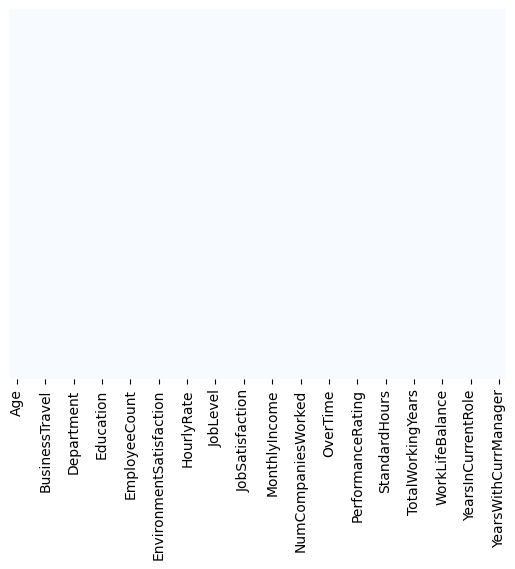

In [7]:
sns.heatmap(employee_df.isnull(), yticklabels=False, cbar=False, cmap='Blues')

array([[<Axes: title={'center': 'Age'}>,
        <Axes: title={'center': 'Attrition'}>,
        <Axes: title={'center': 'DailyRate'}>,
        <Axes: title={'center': 'DistanceFromHome'}>,
        <Axes: title={'center': 'Education'}>],
       [<Axes: title={'center': 'EmployeeCount'}>,
        <Axes: title={'center': 'EmployeeNumber'}>,
        <Axes: title={'center': 'EnvironmentSatisfaction'}>,
        <Axes: title={'center': 'HourlyRate'}>,
        <Axes: title={'center': 'JobInvolvement'}>],
       [<Axes: title={'center': 'JobLevel'}>,
        <Axes: title={'center': 'JobSatisfaction'}>,
        <Axes: title={'center': 'MonthlyIncome'}>,
        <Axes: title={'center': 'MonthlyRate'}>,
        <Axes: title={'center': 'NumCompaniesWorked'}>],
       [<Axes: title={'center': 'Over18'}>,
        <Axes: title={'center': 'OverTime'}>,
        <Axes: title={'center': 'PercentSalaryHike'}>,
        <Axes: title={'center': 'PerformanceRating'}>,
        <Axes: title={'center': 'Relations

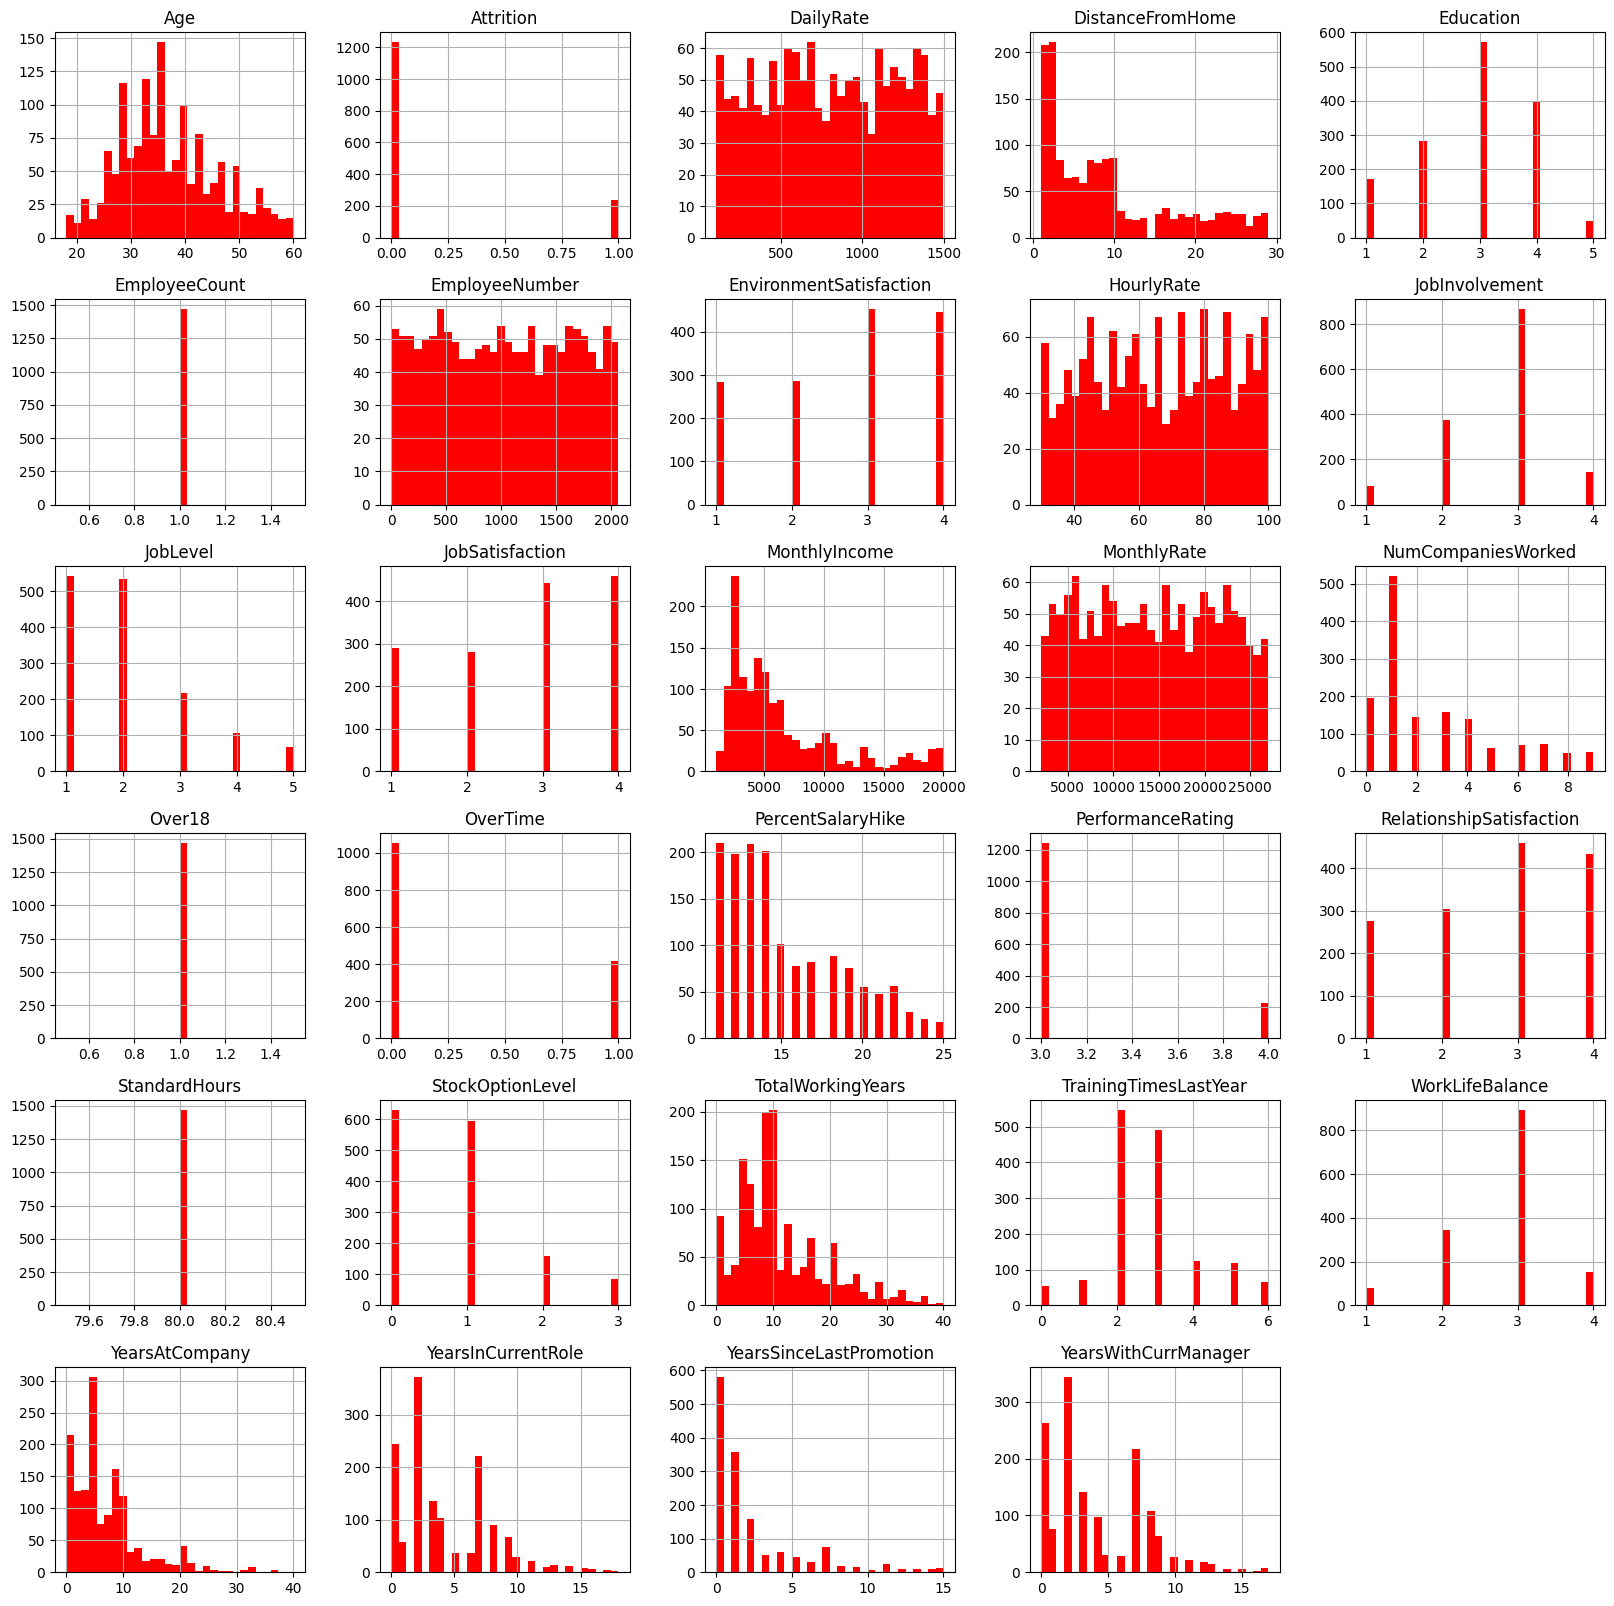

In [8]:
employee_df.hist(bins=30, figsize=(20,20), color='r')

In [9]:
# Eliminar columnas constantes o irrelevantes
employee_df.drop(["EmployeeCount", "StandardHours", "Over18", "EmployeeNumber"], axis=1, inplace=True)
employee_df.shape

(1470, 31)

In [10]:
left_df = employee_df[employee_df['Attrition'] == 1]
stayed_df = employee_df[employee_df['Attrition'] == 0]
print('Total =', len(employee_df))
print('Número de empleados que dejan la empresa =', len(left_df))
print('Porcentaje de empleados que dejan la empresa =', 1.*len(left_df)/len(employee_df)*100.0, '%')
print('Número de empleados que permanecen en la empresa =', len(stayed_df))
print('Porcentaje de empleados que se quedan en la empresa =', 1.*len(stayed_df)/len(employee_df)*100.0, '%')

Total = 1470
Número de empleados que dejan la empresa = 237
Porcentaje de empleados que dejan la empresa = 16.122448979591837 %
Número de empleados que permanecen en la empresa = 1233
Porcentaje de empleados que se quedan en la empresa = 83.87755102040816 %


In [11]:
left_df.describe()
stayed_df.describe()

,Age,Attrition,DailyRate,DistanceFromHome,Education,EnvironmentSatisfaction,HourlyRate,JobInvolvement,JobLevel,JobSatisfaction,...,PerformanceRating,RelationshipSatisfaction,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
count,1233.000000,1233.0,1233.000000,1233.000000,1233.000000,1233.000000,1233.000000,1233.000000,1233.000000,1233.000000,...,1233.000000,1233.000000,1233.000000,1233.000000,1233.000000,1233.000000,1233.000000,1233.000000,1233.000000,1233.000000
mean,37.561233,0.0,812.504461,8.915653,2.927007,2.771290,65.952149,2.770479,2.145985,2.778589,...,3.153285,2.733982,0.845093,11.862936,2.832928,2.781022,7.369019,4.484185,2.234388,4.367397
std,8.888360,0.0,403.208379,8.012633,1.027002,1.071132,20.380754,0.692050,1.117933,1.093277,...,0.360408,1.071603,0.841985,7.760719,1.293585,0.681907,6.096298,3.649402,3.234762,3.594116
min,18.000000,0.0,102.000000,1.000000,1.000000,1.000000,30.000000,1.000000,1.000000,1.000000,...,3.000000,1.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000
25%,31.000000,0.0,477.000000,2.000000,2.000000,2.000000,48.000000,2.000000,1.000000,2.000000,...,3.000000,2.000000,0.000000,6.000000,2.000000,2.000000,3.000000,2.000000,0.000000,2.000000
50%,36.000000,0.0,817.000000,7.000000,3.000000,3.000000,66.000000,3.000000,2.000000,3.000000,...,3.000000,3.000000,1.000000,10.000000,3.000000,3.000000,6.000000,3.000000,1.000000,3.000000
75%,43.000000,0.0,1176.000000,13.000000,4.000000,4.000000,83.000000,3.000000,3.000000,4.000000,...,3.000000,4.000000,1.000000,16.000000,3.000000,3.000000,10.000000,7.000000,3.000000,7.000000
max,60.000000,0.0,1499.000000,29.000000,5.000000,4.000000,100.000000,4.000000,5.000000,4.000000,...,4.000000,4.000000,3.000000,38.000000,6.000000,4.000000,37.000000,18.000000,15.000000,17.000000


Columnas numéricas: ['Age', 'Attrition', 'DailyRate', 'DistanceFromHome', 'Education', 'EnvironmentSatisfaction', 'HourlyRate', 'JobInvolvement', 'JobLevel', 'JobSatisfaction', 'MonthlyIncome', 'MonthlyRate', 'NumCompaniesWorked', 'OverTime', 'PercentSalaryHike', 'PerformanceRating', 'RelationshipSatisfaction', 'StockOptionLevel', 'TotalWorkingYears', 'TrainingTimesLastYear', 'WorkLifeBalance', 'YearsAtCompany', 'YearsInCurrentRole', 'YearsSinceLastPromotion', 'YearsWithCurrManager']


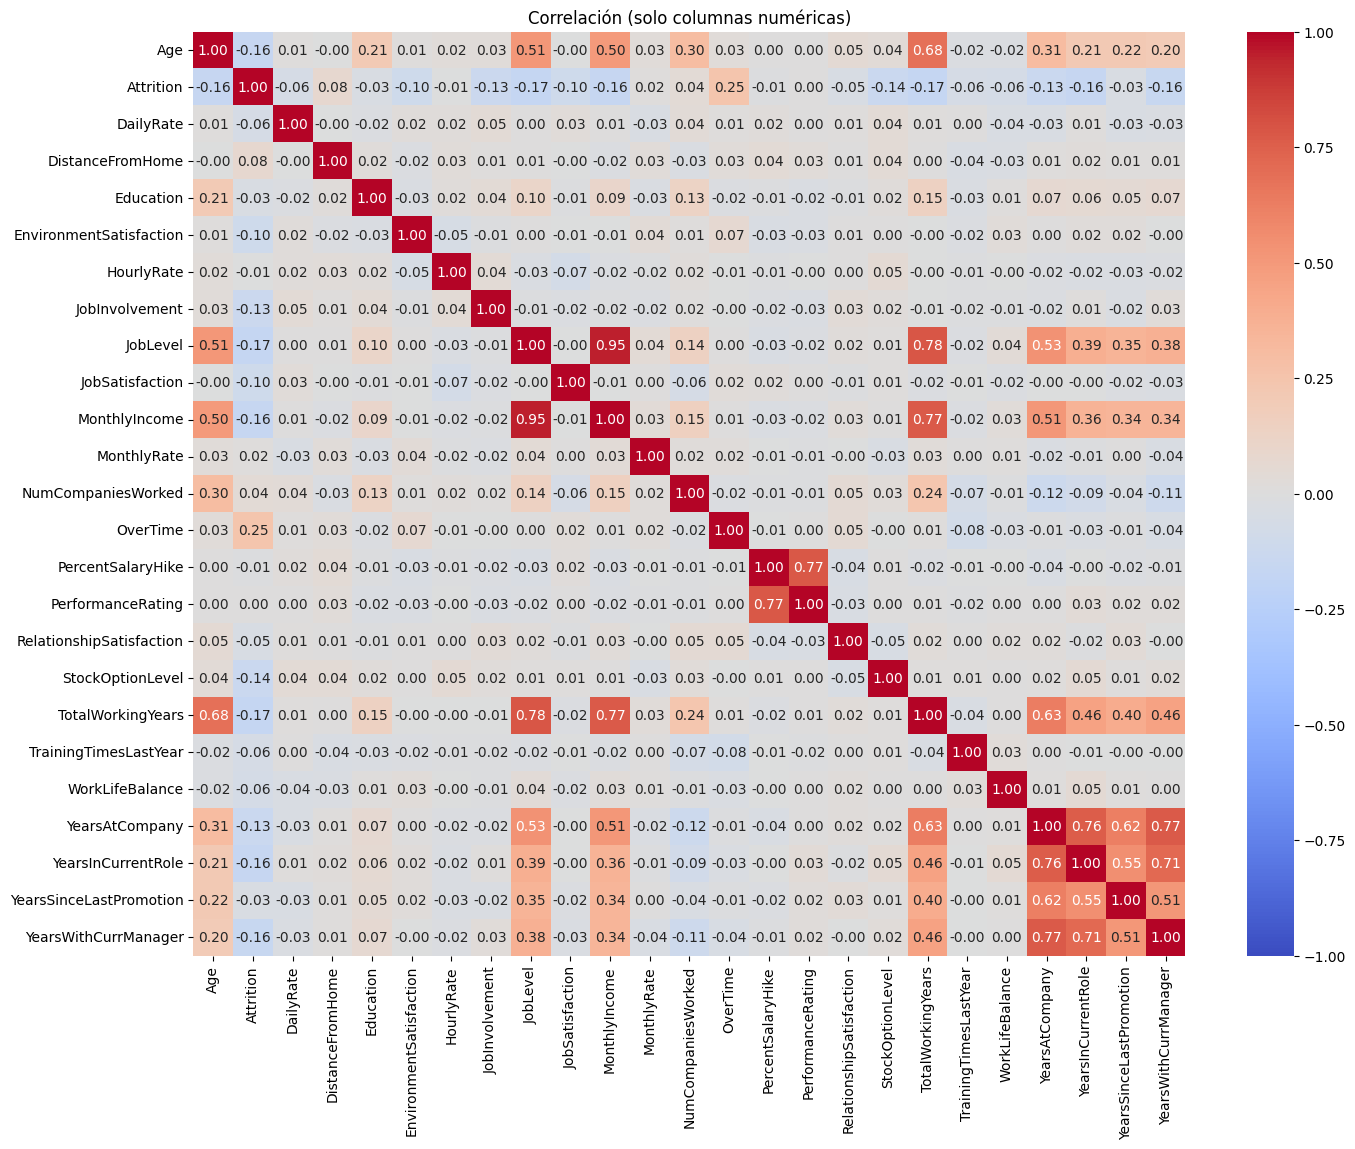

In [12]:
# Opción A: usar sólo columnas numéricas para la matriz de correlación
num_df = employee_df.select_dtypes(include=[np.number])
print('Columnas numéricas:', list(num_df.columns))

corr = num_df.corr()
plt.figure(figsize=(16,12))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', vmin=-1, vmax=1)
plt.title('Correlación (solo columnas numéricas)')
plt.show()

<Axes: xlabel='Age', ylabel='count'>

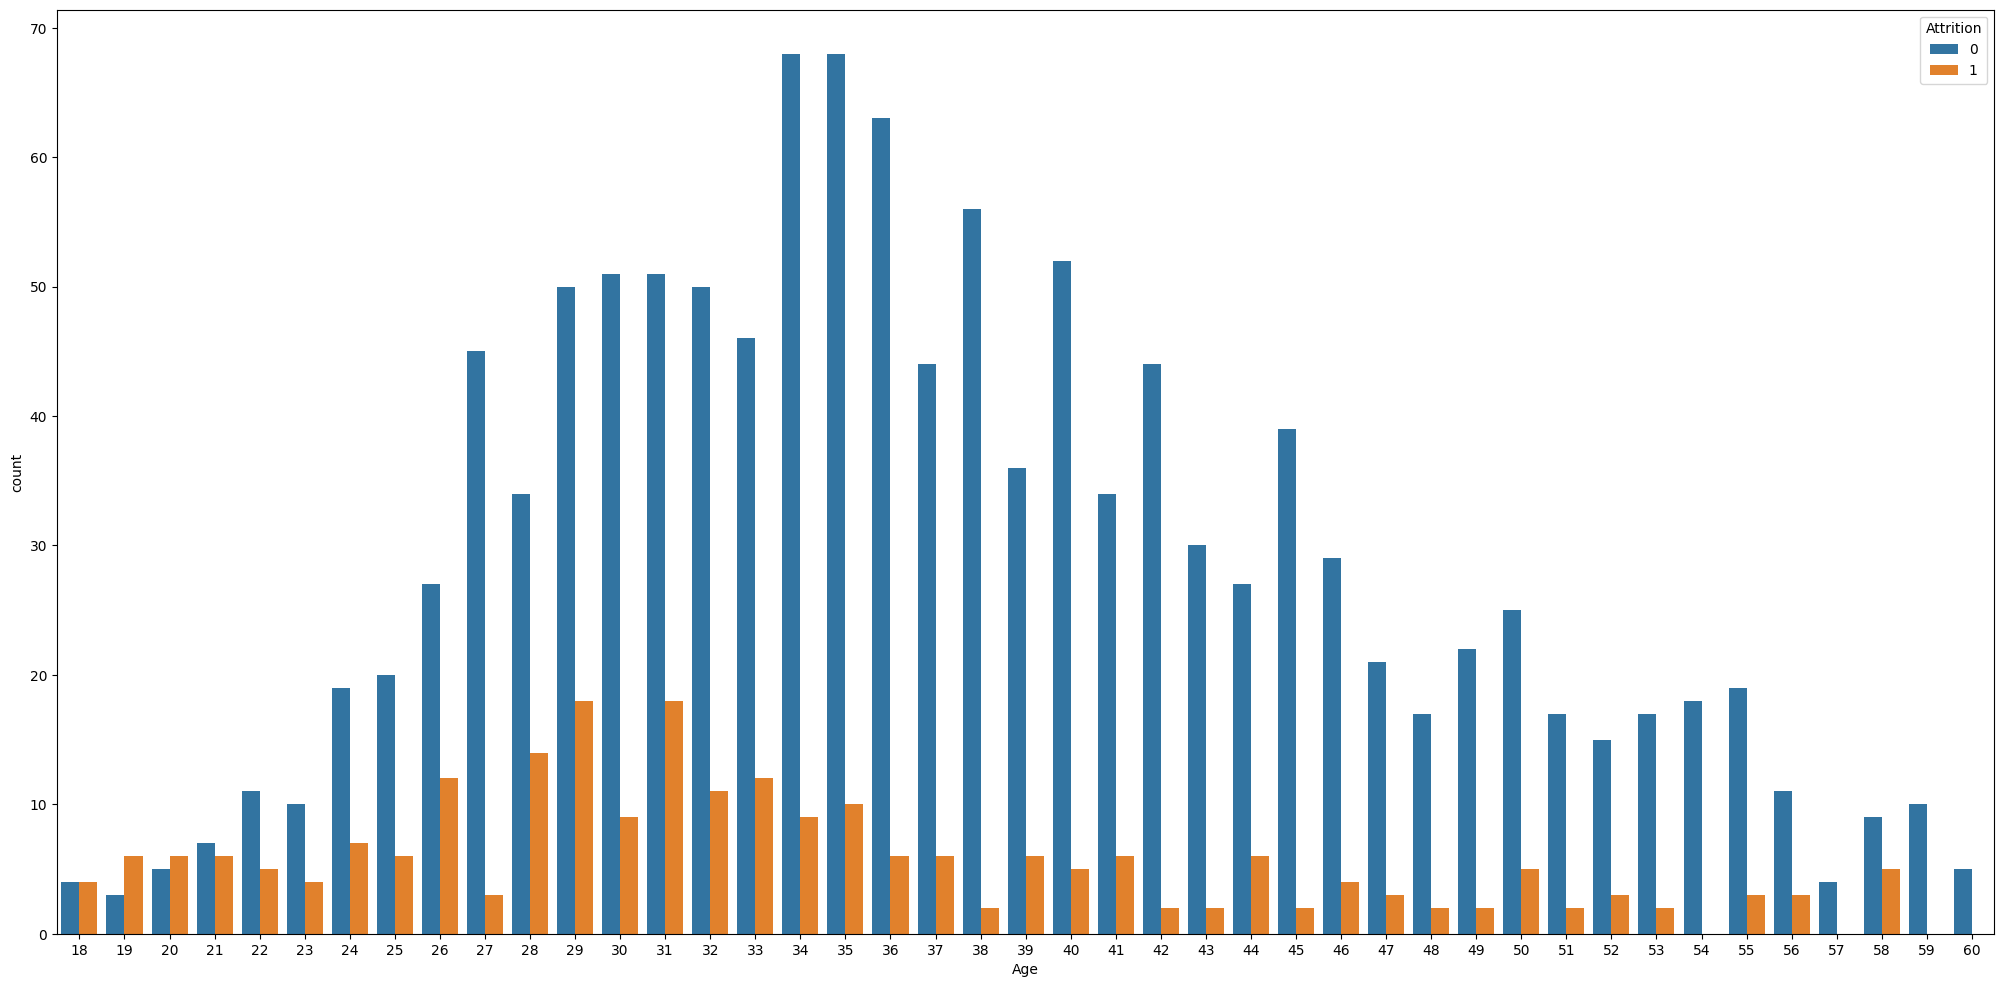

In [13]:
plt.figure(figsize=[25,12])
sns.countplot(x='Age', hue='Attrition', data=employee_df)

<Axes: xlabel='JobLevel', ylabel='count'>

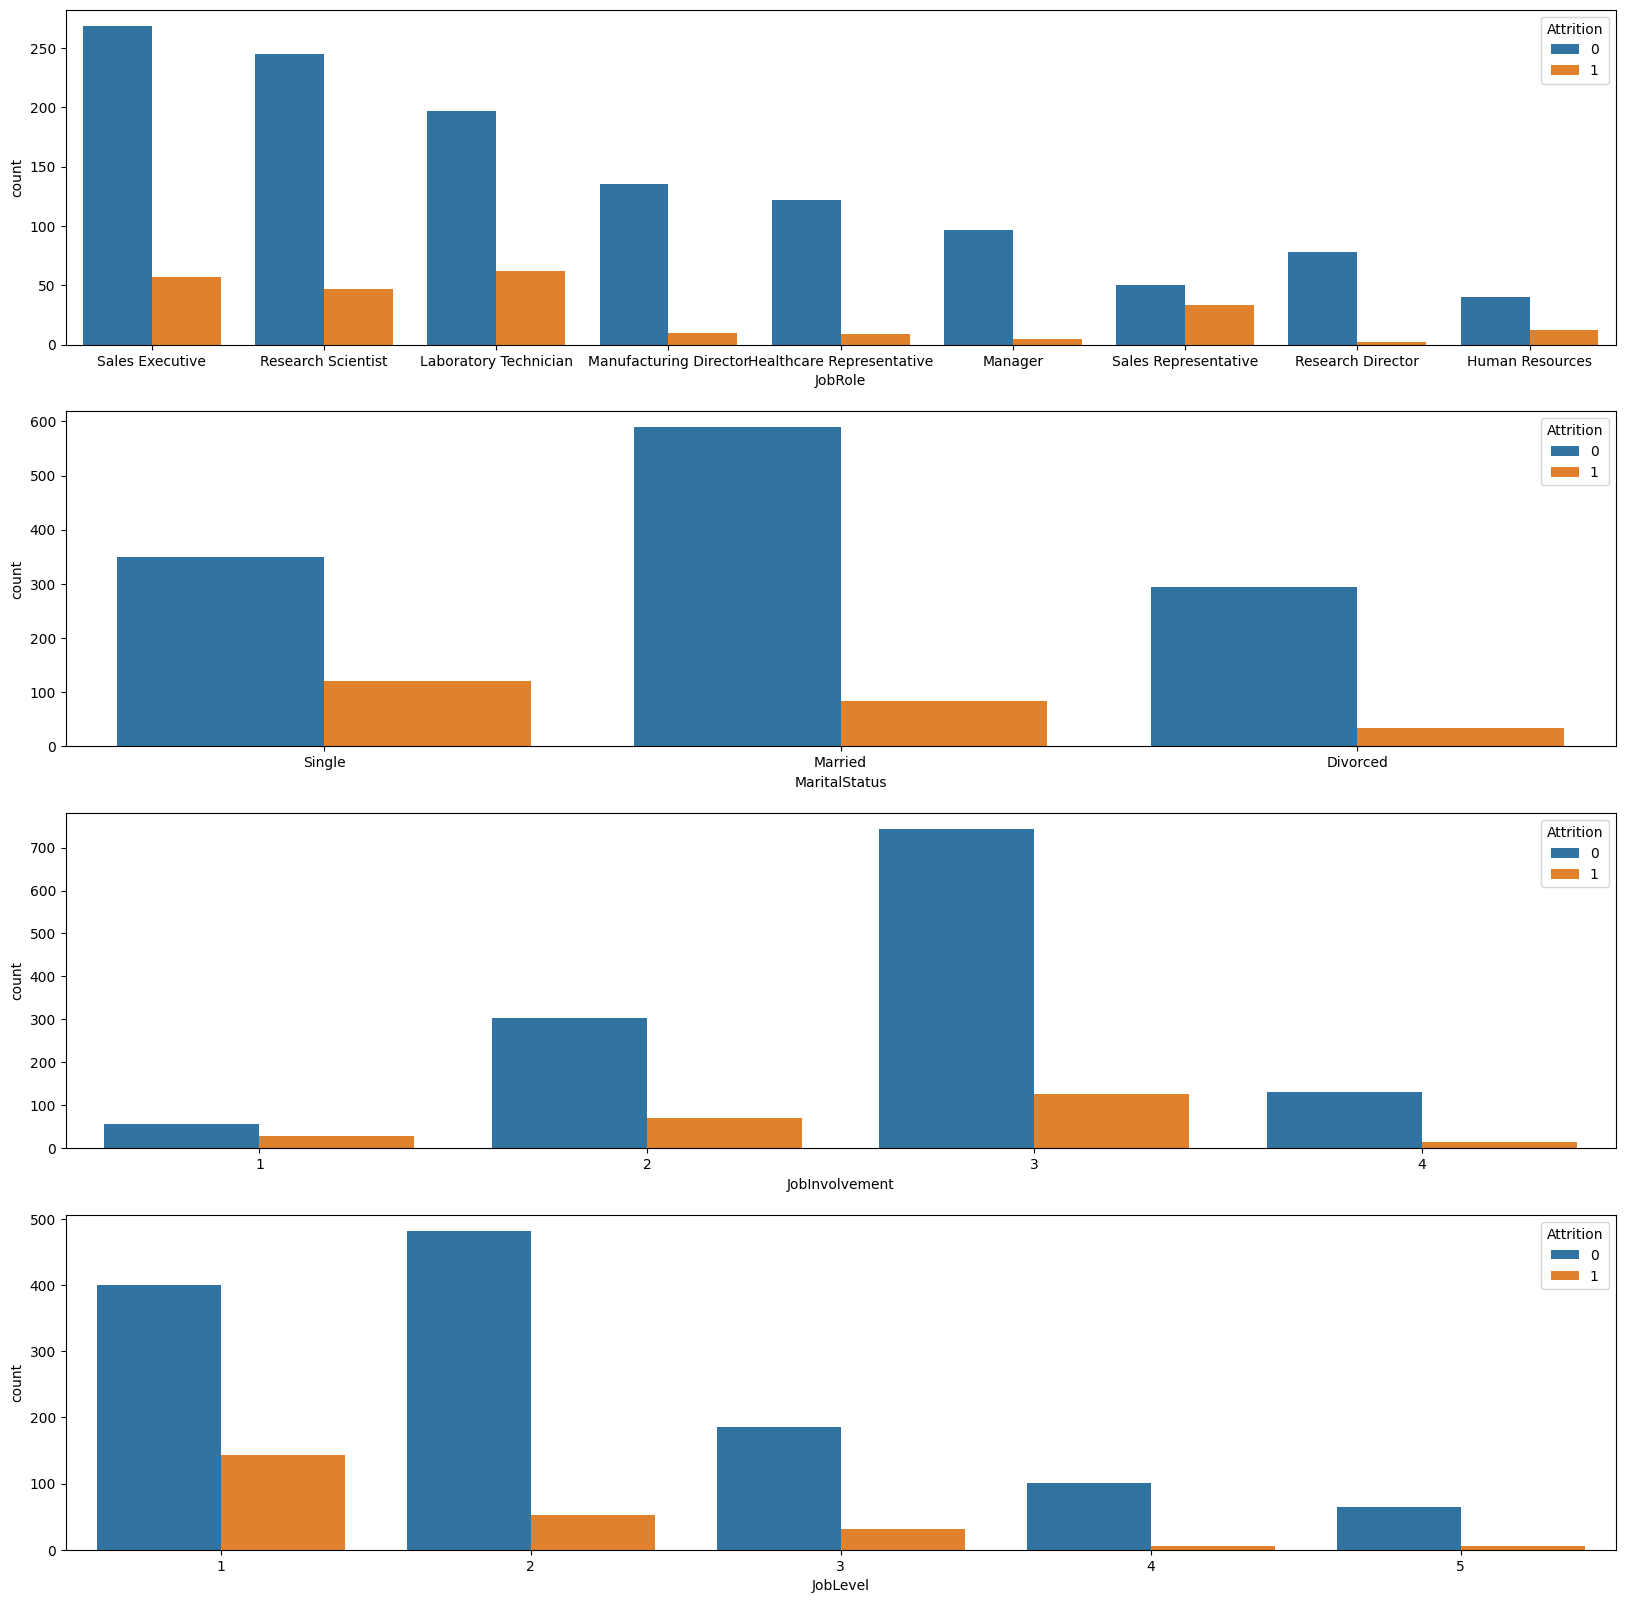

In [14]:
plt.figure(figsize=[20,20])
plt.subplot(411)
sns.countplot(x='JobRole', hue='Attrition', data=employee_df)
plt.subplot(412)
sns.countplot(x='MaritalStatus', hue='Attrition', data=employee_df)
plt.subplot(413)
sns.countplot(x='JobInvolvement', hue='Attrition', data=employee_df)
plt.subplot(414)
sns.countplot(x='JobLevel', hue='Attrition', data=employee_df)

C:\Users\Usuario\AppData\Local\Temp\ipykernel_2752\2404209035.py:2: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

  sns.kdeplot(left_df['DistanceFromHome'], label='Empleados que se marchan', shade=True, color='r')
C:\Users\Usuario\AppData\Local\Temp\ipykernel_2752\2404209035.py:3: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

  sns.kdeplot(stayed_df['DistanceFromHome'], label='Empleados que se quedan', shade=True, color='b')


Text(0.5, 0, 'Distancia desde Casa al Trabajo')

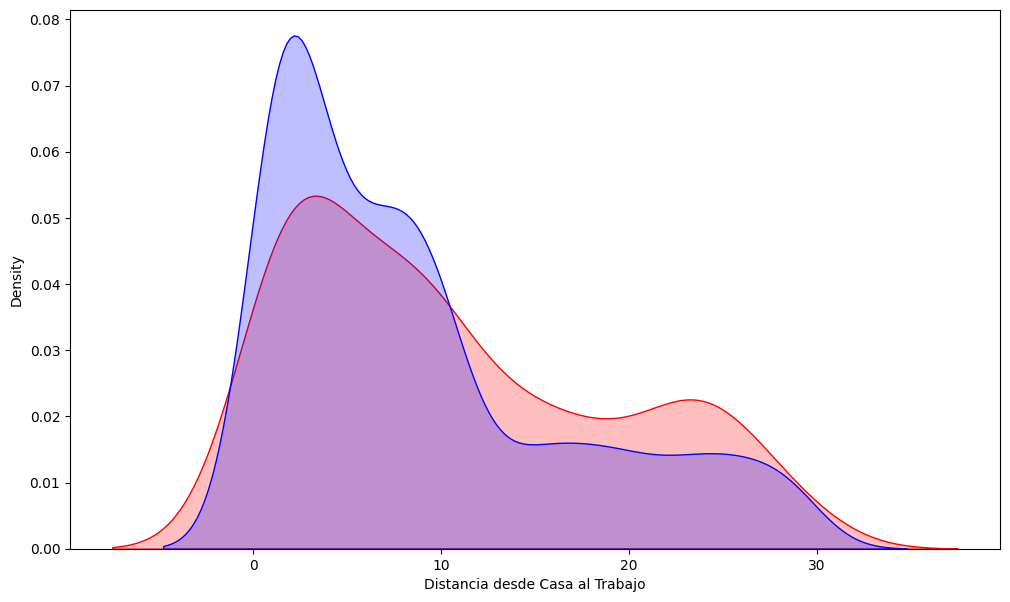

In [15]:
plt.figure(figsize=(12,7))
sns.kdeplot(left_df['DistanceFromHome'], label='Empleados que se marchan', shade=True, color='r')
sns.kdeplot(stayed_df['DistanceFromHome'], label='Empleados que se quedan', shade=True, color='b')
plt.xlabel('Distancia desde Casa al Trabajo')

C:\Users\Usuario\AppData\Local\Temp\ipykernel_2752\2432739180.py:2: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

  sns.kdeplot(left_df['YearsWithCurrManager'], label='Empleados que se marchan', shade=True, color='r')
C:\Users\Usuario\AppData\Local\Temp\ipykernel_2752\2432739180.py:3: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

  sns.kdeplot(stayed_df['YearsWithCurrManager'], label='Empleados que se quedan', shade=True, color='b')


Text(0.5, 0, 'Años con su Manager Actual')

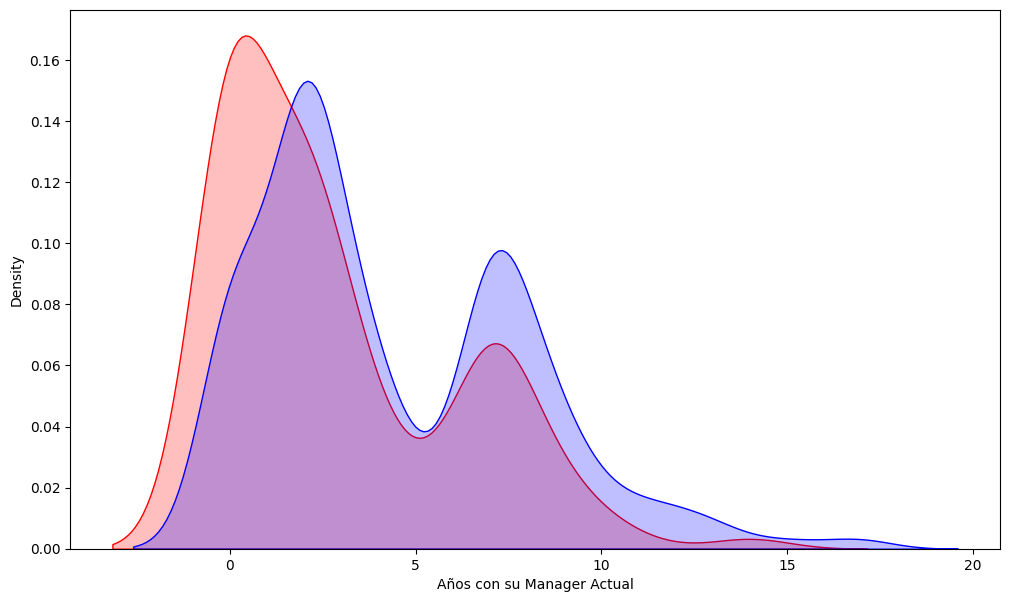

In [16]:
plt.figure(figsize=(12,7))
sns.kdeplot(left_df['YearsWithCurrManager'], label='Empleados que se marchan', shade=True, color='r')
sns.kdeplot(stayed_df['YearsWithCurrManager'], label='Empleados que se quedan', shade=True, color='b')
plt.xlabel('Años con su Manager Actual')

C:\Users\Usuario\AppData\Local\Temp\ipykernel_2752\2673494810.py:2: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

  sns.kdeplot(left_df['TotalWorkingYears'], label='Empleados que se marchan', shade=True, color='r')
C:\Users\Usuario\AppData\Local\Temp\ipykernel_2752\2673494810.py:3: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

  sns.kdeplot(stayed_df['TotalWorkingYears'], label='Empleados que se quedan', shade=True, color='b')


Text(0.5, 0, 'Número total de años de Trabajo')

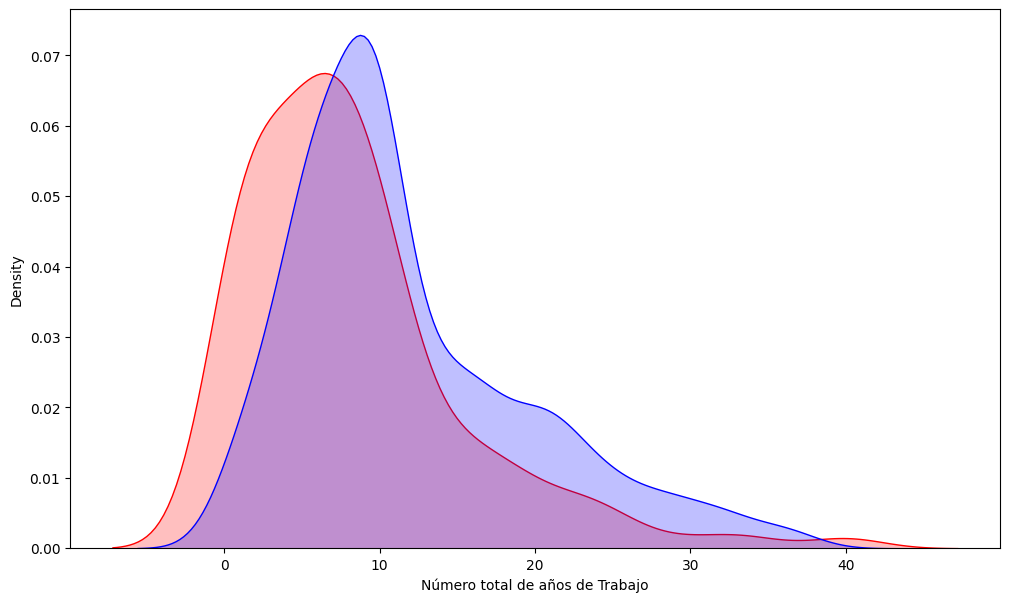

In [17]:
plt.figure(figsize=(12,7))
sns.kdeplot(left_df['TotalWorkingYears'], label='Empleados que se marchan', shade=True, color='r')
sns.kdeplot(stayed_df['TotalWorkingYears'], label='Empleados que se quedan', shade=True, color='b')
plt.xlabel('Número total de años de Trabajo')

<Axes: xlabel='MonthlyIncome', ylabel='Gender'>

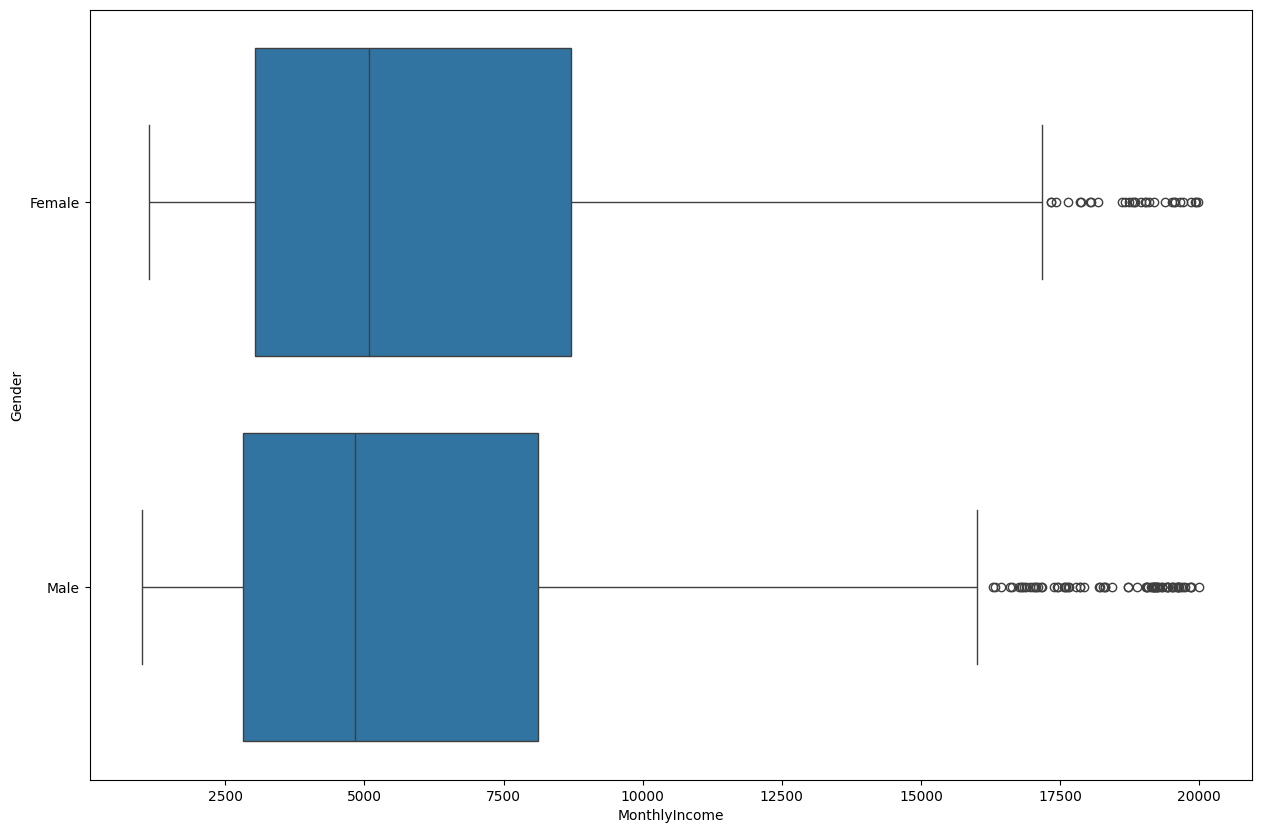

In [18]:
plt.figure(figsize=(15,10))
sns.boxplot(x='MonthlyIncome', y='Gender', data=employee_df)

<Axes: xlabel='MonthlyIncome', ylabel='JobRole'>

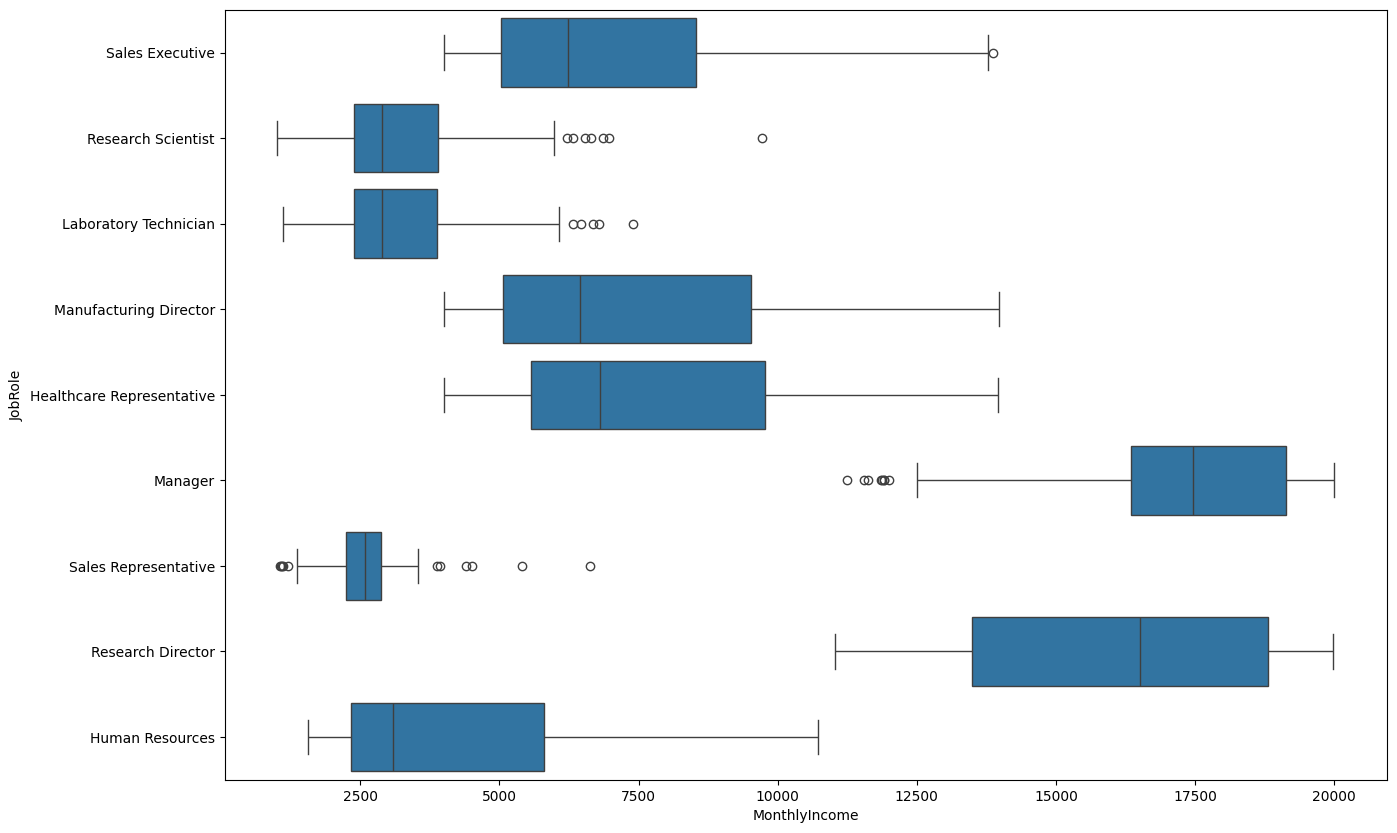

In [19]:
plt.figure(figsize=(15,10))
sns.boxplot(x='MonthlyIncome', y='JobRole', data=employee_df)

In [20]:
# Preparar variables para modelado
X_cat = employee_df[['BusinessTravel', 'Department', 'EducationField', 'Gender', 'JobRole', 'MaritalStatus']]
from sklearn.preprocessing import OneHotEncoder
onehotencoder = OneHotEncoder()
X_cat = onehotencoder.fit_transform(X_cat).toarray()
X_cat = pd.DataFrame(X_cat)
X_numerical = employee_df[['Age', 'DailyRate', 'DistanceFromHome', 'Education', 'EnvironmentSatisfaction', 'HourlyRate', 'JobInvolvement', 'JobLevel', 'JobSatisfaction', 'MonthlyIncome', 'MonthlyRate', 'NumCompaniesWorked', 'OverTime', 'PercentSalaryHike', 'PerformanceRating', 'RelationshipSatisfaction', 'StockOptionLevel', 'TotalWorkingYears', 'TrainingTimesLastYear', 'WorkLifeBalance', 'YearsAtCompany', 'YearsInCurrentRole', 'YearsSinceLastPromotion', 'YearsWithCurrManager']]
X_all = pd.concat([X_cat, X_numerical], axis=1)

In [21]:
from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler()
X_all.columns = X_all.columns.astype(str)
X = scaler.fit_transform(X_all)
y = employee_df['Attrition']

In [22]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42)
X_train.shape

(1102, 50)

Accuracy 89.67391304347827 %
              precision    recall  f1-score   support

           0       0.91      0.97      0.94       320
           1       0.68      0.40      0.50        48

    accuracy                           0.90       368
   macro avg       0.80      0.68      0.72       368
weighted avg       0.88      0.90      0.88       368



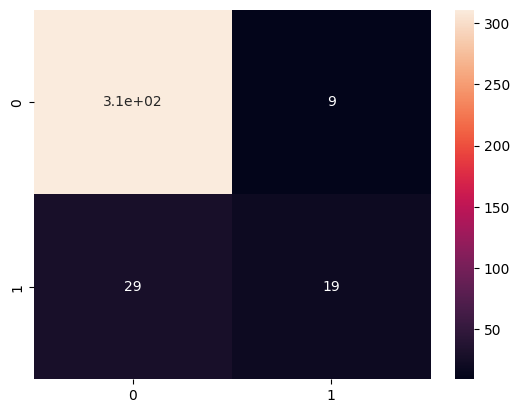

In [23]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)
y_pred = model.predict(X_test)
print('Accuracy {} %'.format(100*accuracy_score(y_pred, y_test)))
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True)
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.88      0.99      0.93       320
           1       0.50      0.06      0.11        48

    accuracy                           0.87       368
   macro avg       0.69      0.53      0.52       368
weighted avg       0.83      0.87      0.82       368



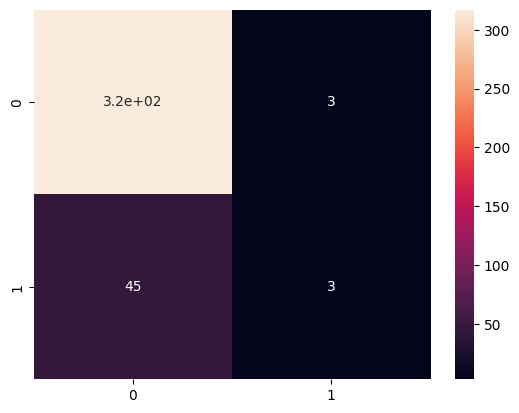

In [24]:
from sklearn.ensemble import RandomForestClassifier
model = RandomForestClassifier(random_state=42)
model.fit(X_train, y_train)
y_pred = model.predict(X_test)
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True)
print(classification_report(y_test, y_pred))

In [ ]:
# Diagnóstico: comprobar protobuf/TensorFlow antes de entrenar
import sys
print('Python', sys.version)
print('Si instalaste paquetes recientemente: reinicia el kernel del notebook antes de ejecutar esta celda (Kernel -> Restart).')

# Informar estado de protobuf
try:
    import google.protobuf as protobuf
    import google.protobuf.internal.api_implementation as api_impl
    import google.protobuf.internal.decoder as decoder
    print('protobuf.__version__ =', getattr(protobuf, '__version__','desconocido'))
    print('api_implementation._c_module presente?:', hasattr(api_impl, '_c_module'))
    print('decoder.SkipField presente?:', hasattr(decoder, 'SkipField'))
except Exception as e:
    print('No se pudo inspeccionar protobuf:', type(e).__name__, e)

# Intentar importar TensorFlow
try:
    import tensorflow as tf
    print('TensorFlow importado correctamente. Versión:', tf.__version__)
    try:
        gpus = tf.config.list_physical_devices('GPU')
        print('GPUs detectadas:', gpus)
    except Exception as _g:
        print('No se pudo consultar GPUs:', _g)
    tf_ok = True
except Exception as e:
    print('Error al importar TensorFlow:', type(e).__name__, e)
    tf_ok = False

if not tf_ok:
    print('\nSugerencias si aparece un error tipo AttributeError relacionado con protobuf:')
    print('- Reinicia el kernel del notebook y vuelve a intentar.')
    print('- Forzar reinstalación de una versión compatible de protobuf:')
    print("  python -m pip uninstall -y protobuf; python -m pip install protobuf==3.20.3")
    print('- Si continúa, reinstala TensorFlow: python -m pip install --upgrade --force-reinstall tensorflow')
    print('- Si usas Python 3.13 considera crear un entorno con Python 3.10 o 3.11 e instalar allí TensorFlow.')
else:
    from sklearn.metrics import confusion_matrix, classification_report
    import numpy as np

    # Verificar que X_train esté preparado
    if 'X_train' not in globals() or 'y_train' not in globals():
        raise RuntimeError('X_train/y_train no definidos. Ejecuta las celdas previas que preparan los datasets para entrenamiento.')

    input_dim = X_train.shape[1]

    model_dl = tf.keras.models.Sequential([
        tf.keras.layers.Dense(128, activation='relu', input_shape=(input_dim,)),
        tf.keras.layers.Dropout(0.3),
        tf.keras.layers.Dense(64, activation='relu'),
        tf.keras.layers.Dense(1, activation='sigmoid')
    ])

    model_dl.compile(optimizer='Adam', loss='binary_crossentropy', metrics=['accuracy'])

    # Entrenamiento breve por defecto (ajusta epochs/batch_size según hardware)
    print('Entrenando modelo (epochs=5, batch_size=32) — esto puede tardar...')
    epochs_hist = model_dl.fit(X_train, y_train, epochs=5, batch_size=32, verbose=1)

    # Predicción y evaluación
    y_pred_dl = model_dl.predict(X_test)
    y_pred_dl = (y_pred_dl > 0.5).astype(int).reshape(-1)

    cm = confusion_matrix(y_test, y_pred_dl)
    print('Confusion matrix:')
    print(cm)
    sns.heatmap(cm, annot=True, fmt='d')
    print('\nClassification report:')
    print(classification_report(y_test, y_pred_dl))

AttributeError: module 'google.protobuf.internal.decoder' has no attribute 'SkipField'

Sugerencias:
- Revisa compatibilidad de TensorFlow con tu versión de Python (usa Python 3.8–3.11 si hay problemas).
- Si usas GPU en Windows, asegúrate de instalar CUDA/cuDNN compatibles; si no, instala la build CPU de TensorFlow.
